In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.data import (
    load_data,
    create_weekly_sales
)

from src.features import (
    create_features,
    time_based_split
)

from src.forecasting import (
    baseline_forecast,
    train_model,
    predict_model,
    create_forecast_results
)

from src.inventory import (
    create_inventory_snapshot,
    simulate_inventory,
    calculate_inventory_gaps
)

from src.allocation import (
    build_reallocation_plan,
    apply_transfer_plan,
    calculate_allocation_kpis
)

In [3]:
sales, stores = load_data()

weekly_sales = create_weekly_sales(sales)

df = create_features(weekly_sales)

train_df, test_df = time_based_split(df)

In [4]:
baseline_pred, baseline_metrics = baseline_forecast(
    test_df
)

model = train_model(
    train_df
)

ml_pred, ml_metrics = predict_model(
    model,
    test_df
)

results = create_forecast_results(
    test_df,
    baseline_pred,
    ml_pred
)

In [5]:
# inventory
snapshot = create_inventory_snapshot(
    results,
    stores
)

snapshot = simulate_inventory(
    snapshot
)

snapshot = calculate_inventory_gaps(
    snapshot
)

In [6]:
print("Decision week:",
      snapshot["week"].max())

print("Snapshot rows:",
      len(snapshot))

print("Forecast demand total:",
      f"{snapshot['forecast_demand'].sum():,.0f}")

print("Current inventory total:",
      f"{snapshot['current_inventory'].sum():,.0f}")

print("Target inventory total:",
      f"{snapshot['target_inventory'].sum():,.0f}")

print("Initial shortage:",
      f"{snapshot['shortage_units'].sum():,.0f}")

print("Initial surplus:",
      f"{snapshot['surplus_units'].sum():,.0f}")

Decision week: 2017-08-07 00:00:00
Snapshot rows: 1782
Forecast demand total: 5,699,407
Current inventory total: 6,917,615
Target inventory total: 6,839,331
Initial shortage: 795,156
Initial surplus: 832,154


In [7]:
# allocation
transfer_plan = build_reallocation_plan(
    snapshot
)

post_snapshot = apply_transfer_plan(
    snapshot,
    transfer_plan
)

kpis = calculate_allocation_kpis(
    snapshot,
    transfer_plan,
    post_snapshot
)

kpis

{'initial_shortage': np.int64(795156),
 'initial_surplus': np.int64(832154),
 'units_reallocated': np.int64(708508),
 'remaining_shortage': np.float64(86648.0),
 'shortage_coverage': np.float64(89.10301877870506),
 'surplus_utilization': np.float64(85.14145218312956),
 'number_of_transfers': 963}

In [8]:
expected_remaining = (
    snapshot["shortage_units"].sum()
    - transfer_plan["units"].sum()
)

actual_remaining = (
    post_snapshot[
        "post_shortage_units"
    ].sum()
)

assert (
    expected_remaining
    == actual_remaining
), "Allocation sanity check failed"

print(
    "Sanity check passed:",
    f"{actual_remaining:,.0f}"
)

Sanity check passed: 86,648


In [9]:
print(
    "Initial shortage     :",
    f"{snapshot['shortage_units'].sum():,.0f}"
)

print(
    "Initial surplus      :",
    f"{snapshot['surplus_units'].sum():,.0f}"
)

print(
    "Units reallocated    :",
    f"{transfer_plan['units'].sum():,.0f}"
)

print(
    "Remaining shortage   :",
    f"{post_snapshot['post_shortage_units'].sum():,.0f}"
)

print(
    "Number of transfers  :",
    f"{len(transfer_plan):,}"
)

print("\nBaseline metrics:")
print(baseline_metrics)

print("\nML metrics:")
print(ml_metrics)

Initial shortage     : 795,156
Initial surplus      : 832,154
Units reallocated    : 708,508
Remaining shortage   : 86,648
Number of transfers  : 963

Baseline metrics:
{'MAE': 314.9867507303732, 'WAPE': np.float64(9.494514815851637)}

ML metrics:
{'MAE': 268.1142992501282, 'WAPE': np.float64(8.081657976627255)}


In [11]:
from src.visualization import (
    plot_forecast_results,
    plot_shortage_before_after
)

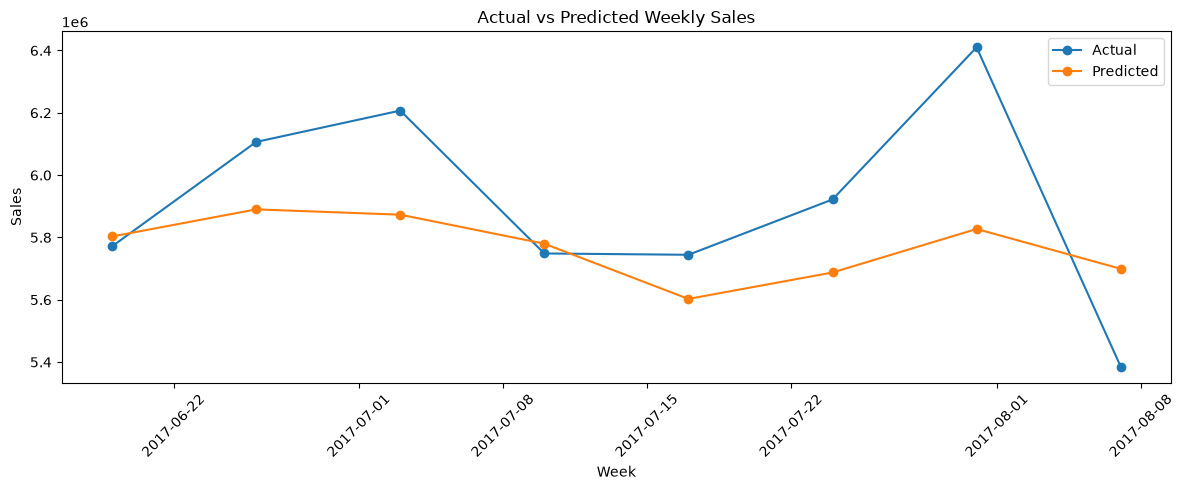

In [12]:
plot_forecast_results(
    results,
    "../assets/forecast_actual_vs_predicted.png"
)

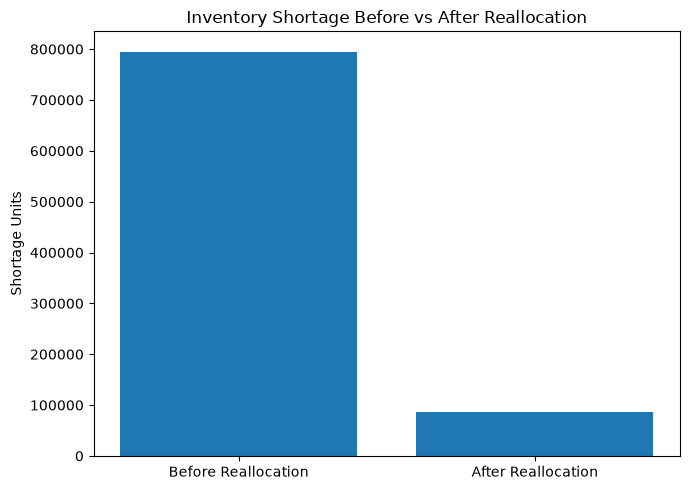

In [13]:
plot_shortage_before_after(
    kpis["initial_shortage"],
    kpis["remaining_shortage"],
    "../assets/shortage_before_after.png"
)